In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./Dataset/customer.csv')

In [3]:
df.shape

(64374, 12)

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Female    34353
Male      30021
Name: count, dtype: int64

In [9]:
df.drop('CustomerID',axis=1,inplace=True)

In [10]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [11]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [12]:
df['Subscription Type'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [13]:
df['Contract Length'].unique()

array(['Monthly', 'Annual', 'Quarterly'], dtype=object)

In [14]:
df=pd.get_dummies(df, columns=['Gender', 'Subscription Type','Contract Length'], drop_first=True, dtype=int)

In [15]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,0,1,1,0
2,47,27,10,2,29,757,21,0,1,1,0,0,0
3,35,9,12,5,17,232,18,0,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,0,1,0,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         64374 non-null  int64
 1   Tenure                      64374 non-null  int64
 2   Usage Frequency             64374 non-null  int64
 3   Support Calls               64374 non-null  int64
 4   Payment Delay               64374 non-null  int64
 5   Total Spend                 64374 non-null  int64
 6   Last Interaction            64374 non-null  int64
 7   Churn                       64374 non-null  int64
 8   Gender_Male                 64374 non-null  int64
 9   Subscription Type_Premium   64374 non-null  int64
 10  Subscription Type_Standard  64374 non-null  int64
 11  Contract Length_Monthly     64374 non-null  int64
 12  Contract Length_Quarterly   64374 non-null  int64
dtypes: int64(13)
memory usage: 6.4 MB


In [17]:
x=df.drop('Churn',axis=1)

In [18]:
x.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,1,1,0
2,47,27,10,2,29,757,21,1,1,0,0,0
3,35,9,12,5,17,232,18,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,1,0,0


In [19]:
x.shape

(64374, 12)

In [20]:
y=df['Churn']

In [21]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=1)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model=Sequential()

In [25]:
model.add(Dense(3,activation='sigmoid', input_dim=12))
model.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (172.00 B)

 Trainable params: 43 (172.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [28]:
model.fit(xtrain,ytrain,epochs=20)

Epoch 1/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.6920
Epoch 2/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6000
Epoch 3/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5217
Epoch 4/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.5050
Epoch 5/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4955
Epoch 6/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4844
Epoch 7/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4729
Epoch 8/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4608
Epoch 9/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4525
Epoch 10/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4455
Epoch 11/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4398
Epoch 12/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4351
Epoch 13/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4286
Epoch 14/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4221
Epoch 15/20
1610/1610 ━━━━━━━

In [29]:
model.layers[0].get_weights()

[array([[ 0.24747407,  0.5484759 , -0.01030802],
        [ 0.5034012 , -0.56922996, -0.03204678],
        [ 0.5322016 ,  0.60176116,  0.05271243],
        [ 0.45412868, -0.15800229, -0.29941306],
        [ 0.5783252 ,  0.22603565, -0.1961106 ],
        [ 0.14990705,  0.47634274,  0.00136405],
        [ 0.36738688,  0.6228965 ,  0.0064075 ],
        [ 0.31013888, -0.10547173,  1.1184093 ],
        [ 0.40496856, -0.6299548 ,  0.19054295],
        [ 0.59969944, -0.17263186,  0.13736075],
        [-0.3646611 , -0.31151456, -0.16942868],
        [ 0.5950776 ,  0.5580589 ,  0.2572021 ]], dtype=float32),
 array([0.       , 0.       , 4.3123455], dtype=float32)]

In [30]:
model.layers[1].get_weights()

[array([[ 0.3622426],
        [ 1.2039508],
        [-5.5814004]], dtype=float32),
 array([1.0140944], dtype=float32)]

In [31]:
model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.56197524],
       [0.7966516 ],
       [0.8543299 ],
       ...,
       [0.9142713 ],
       [0.09655276],
       [0.05410805]], shape=(12875, 1), dtype=float32)

In [32]:
xtest_prob=model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
ypred=np.where(xtest_prob>0.5,1,0)

In [34]:
ypred

array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [0]], shape=(12875, 1))

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.8276504854368932

# Modified

In [36]:
model1=Sequential()

In [37]:
model1.add(Dense(12,activation='relu', input_dim=12))
model1.add(Dense(12, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model1.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [40]:
history=model1.fit(xtrain,ytrain, epochs=20, validation_split=0.2)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7245 - loss: 0.9794 - val_accuracy: 0.7844 - val_loss: 0.4695
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7791 - loss: 0.4661 - val_accuracy: 0.7975 - val_loss: 0.4376
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8039 - loss: 0.4270 - val_accuracy: 0.8158 - val_loss: 0.3983
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8069 - loss: 0.4220 - val_accuracy: 0.8242 - val_loss: 0.3911
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8163 - loss: 0.4017 - val_accuracy: 0.8221 - val_loss: 0.3774
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8257 - loss: 0.3764 - val_accuracy: 0.8384 - val_loss: 0.3479
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8339 - loss: 0.3598 - val_accuracy: 0.8514 - val_loss: 0.3334
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8410 - loss: 0.3440 - 

In [41]:
history.history

{'accuracy': [0.7245078682899475,
  0.7791451215744019,
  0.8039273023605347,
  0.8068885207176208,
  0.8163304924964905,
  0.8256511092185974,
  0.8339037299156189,
  0.8409912586212158,
  0.8474720120429993,
  0.8503847122192383,
  0.8524478673934937,
  0.8524478673934937,
  0.8559430837631226,
  0.8570839166641235,
  0.8568654656410217,
  0.858831524848938,
  0.8604577779769897,
  0.8675938844680786,
  0.8819146156311035,
  0.8893662691116333],
 'loss': [0.9793554544448853,
  0.4661440849304199,
  0.42701810598373413,
  0.4219523072242737,
  0.4016907215118408,
  0.37636762857437134,
  0.35984474420547485,
  0.3439668118953705,
  0.3346734046936035,
  0.326547235250473,
  0.32145455479621887,
  0.31968799233436584,
  0.3140285611152649,
  0.31038516759872437,
  0.3094029426574707,
  0.30859947204589844,
  0.30407968163490295,
  0.29080769419670105,
  0.2635148763656616,
  0.24967540800571442],
 'val_accuracy': [0.7843689322471619,
  0.7974757552146912,
  0.8158252239227295,
  0.8241

In [42]:
model1.layers[0].get_weights()

[array([[ 3.03661138e-01, -1.21089697e-01,  2.86132097e-01,
          5.34513779e-02, -1.27409503e-01,  3.47570628e-01,
          1.75568178e-01,  2.83738732e-01, -9.34195146e-02,
         -2.47545809e-01, -2.15495467e-01, -1.45413637e-01],
        [ 2.07149297e-01,  3.75049591e-01, -2.69613951e-01,
          2.49457881e-01,  1.70818925e-01,  1.13568630e-03,
         -3.01587909e-01,  1.69191703e-01, -2.85725184e-02,
         -2.20541954e-01,  1.14585638e-01, -1.55682087e-01],
        [ 1.65632926e-02,  9.47405100e-02, -1.03158462e+00,
          8.73592123e-02, -3.91364023e-02,  3.35201889e-01,
         -1.32469162e-01,  2.24173851e-02,  1.64432788e+00,
          5.26549369e-02,  1.63931608e-01,  1.07286096e-01],
        [-1.35352218e+00,  7.41077662e-02, -5.24353564e-01,
          2.95778334e-01,  2.56276876e-01, -6.18877336e-02,
          1.85530925e+00, -1.82321280e-01, -1.35769904e+00,
         -2.25881308e-01, -7.30607510e-02,  1.41040802e-01],
        [ 1.39139518e-01,  3.9779067

In [43]:
model1.layers[1].get_weights()

[array([[ 2.9467326e-02, -3.5192899e-02, -4.1087300e-02, -1.8275855e-01,
         -1.5905468e-01,  5.9526616e-01,  2.6368868e-01, -2.0919466e-01,
         -7.0314065e-02, -2.8348303e-01, -1.0506206e-01, -3.2864243e-01],
        [ 4.7833478e-01, -1.1356950e-01, -1.1160624e-01,  1.7326641e-01,
         -1.4083564e-01,  4.8322415e-01, -1.3830960e-01,  1.0168421e-01,
          4.5195210e-01, -1.7893255e-01, -4.6671498e-01,  4.1355145e-01],
        [-2.8584740e-01, -1.4147358e-01, -3.1238210e-01,  1.8417586e-01,
         -4.9787378e-01,  1.4655565e-01,  1.2125517e-01, -4.8088658e-01,
          9.6764885e-02, -7.3940814e-02,  3.7105584e-01, -2.7337620e-01],
        [ 2.2228388e-01,  3.2727537e-01, -8.7061393e-01, -4.0557277e-01,
          4.1535991e-01, -7.5550240e-01, -8.0056578e-02, -4.7555935e-01,
         -1.8127650e-01, -2.0808388e-01,  4.1482934e-01, -9.2267171e-02],
        [ 2.4250610e-01,  6.3173413e-02,  4.3032828e-01, -2.3621616e-01,
         -2.9907951e-01,  1.3732767e-01,  2.071

In [44]:
xtest_pro=model1.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [45]:
ypred=np.where(xtest_pro>0.5,1,0)

In [46]:
accuracy_score(ytest,ypred)

0.8938252427184467

In [47]:
import matplotlib.pyplot as plt

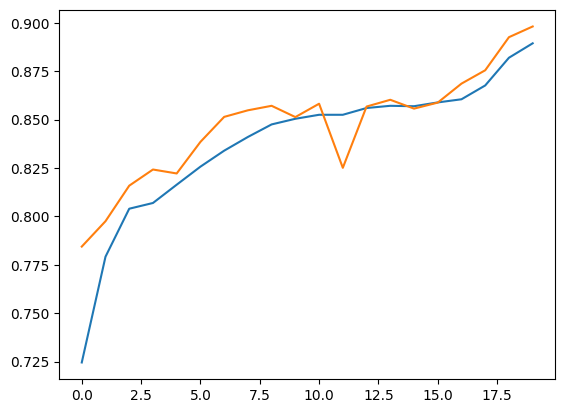

In [48]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

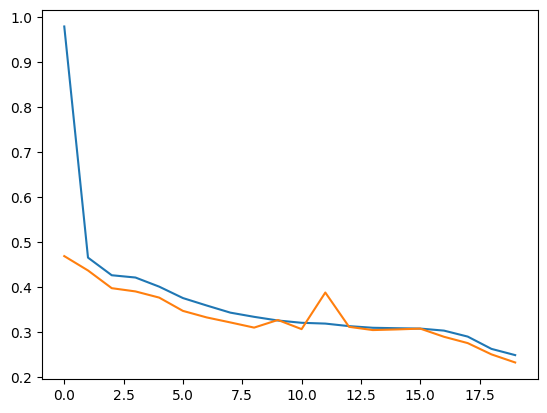

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
# Model 6: LeakyReLU activation, binary_crossentropy loss
from tensorflow.keras.layers import LeakyReLU
model6 = Sequential()
model6.add(Dense(12, input_dim=12))
model6.add(LeakyReLU(alpha=0.1))
model6.add(Dense(12))
model6.add(LeakyReLU(alpha=0.1))
model6.add(Dense(1, activation='sigmoid'))
model6.summary()
model6.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
history6 = model6.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

In [ ]:
# Model 7: SELU activation, mean_absolute_error loss
model7 = Sequential()
model7.add(Dense(12, activation='selu', input_dim=12))
model7.add(Dense(12, activation='selu'))
model7.add(Dense(1, activation='sigmoid'))
model7.summary()
model7.compile(loss='mean_absolute_error', optimizer='Adam', metrics=['accuracy'])
history7 = model7.fit(xtrain, ytrain, epochs=20, validation_split=0.2)